In [21]:
#Step1: Import libraries
print("\n----------------------------------")
print(" Import libraries and set filepath")
print("----------------------------------")
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
print("Imported.....")

try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
DATA_RAW = "diabetes.csv"
DATA_CLEAN = "diabetes_cleaned.csv"
PLOT_BEFORE = "barchart_basedon_outcomes.png"
PREDICTION_RESULT = "diabetese_prediction_result.csv"
EVALUATION_REPORT = "model_evaluation.txt"
TREE_RULE = "diabetes_prediction_tree_rules.txt"
print("Path set.....")
print("Done.....")


----------------------------------
 Import libraries and set filepath
----------------------------------
Imported.....
Path set.....
Done.....


In [22]:
#Step2: Load from CSV
print("\n----------------------------------")
print("        Load and analyse data")
print("----------------------------------")
df = pd.read_csv(DATA_DIR / DATA_RAW)

print("\nDaibetes Dataset (First five rows):")
print("-------------------------------------")
print(df.head())

print("\nDataset info:")
print("-----------------")
print(df.info())

print("\nDataset describe:")
print("-----------------")
print(df.describe())
print("\nDone.........")


----------------------------------
        Load and analyse data
----------------------------------

Daibetes Dataset (First five rows):
-------------------------------------
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset info:
-----------------
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 

In [23]:
# %% #Step3: Clean Dataset
print("\n----------------------------------")
print("     Cleaning data")
print("----------------------------------")

print(f"Column: {list(df.columns)}")
print("\nMissing values :")
print("---------------------------")
print(df.isna().sum())


print("\nRows with 0 in more than 3 column")
print("----------------------------------")
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
    
# drop rows with more than 3 0 values, it can be crapy row 
zero_counts_per_row = (df[zero_as_missing_cols] == 0).sum(axis=1)
rows_to_drop = zero_counts_per_row > 3


print(f"\nRows with more than 3 zero values in columns (to be dropped): {rows_to_drop.sum()}")
df = df[~rows_to_drop].reset_index(drop=True)
print(f"Shape after dropping those rows: {df.shape}")

# after droping rows with more than 3 0 values
print("\nColumns with unrealistic 0 values left:")
print("----------------------------------")
for col in zero_as_missing_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} / {len(df)} entries")


# replace 0 with NaN
df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("\nAfter replacing 0 with NaN:")
print("----------------------------------")
for col in zero_as_missing_cols:
    zero_count = (df_clean[col] == 0).sum()
    print(f"{col}: {zero_count} / {len(df)} entries")

print("\nMissing values after converting 0 -> NaN")
print("------------------------------------------")
print(df_clean.isnull().sum())

print("\nFilling with median considering outcome column")
print("------------------------------------------")
def fill_with_median(x):
    """Fill missing values in a column with that column's own median."""
    return x.fillna(x.median())

for col in zero_as_missing_cols:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(fill_with_median)

print("\nConvert to int for some columns")
print("------------------------------------------")
int_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin"]
for col in int_cols:
    df_clean[col] = df_clean[col].round().astype(int)

print("\nMissing values after adding median:")
print("------------------------------------------")
print(df_clean.isnull().sum())

print("\nCleaned Dataset info:")
print("-----------------")
print(df_clean.info())

print("\nDescribe Cleaned data:")
print("------------------------------------------")
print(df_clean.describe())

df_clean.to_csv(DATA_DIR / DATA_CLEAN, index=False)
print(f"\nCleaned dataset saved to: {DATA_DIR / DATA_CLEAN}")
print("\nDone.....")



----------------------------------
     Cleaning data
----------------------------------
Column: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values :
---------------------------
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Rows with 0 in more than 3 column
----------------------------------

Rows with more than 3 zero values in columns (to be dropped): 7
Shape after dropping those rows: (761, 9)

Columns with unrealistic 0 values left:
----------------------------------
Glucose: 5 / 761 entries
BloodPressure: 28 / 761 entries
SkinThickness: 220 / 761 entries
Insulin: 367 / 761 entries
BMI: 4 / 761 entries

After replacing 0 with NaN:
----------------------------


----------------------------------
          Visualise Data Set
----------------------------------
Saved bar plot before


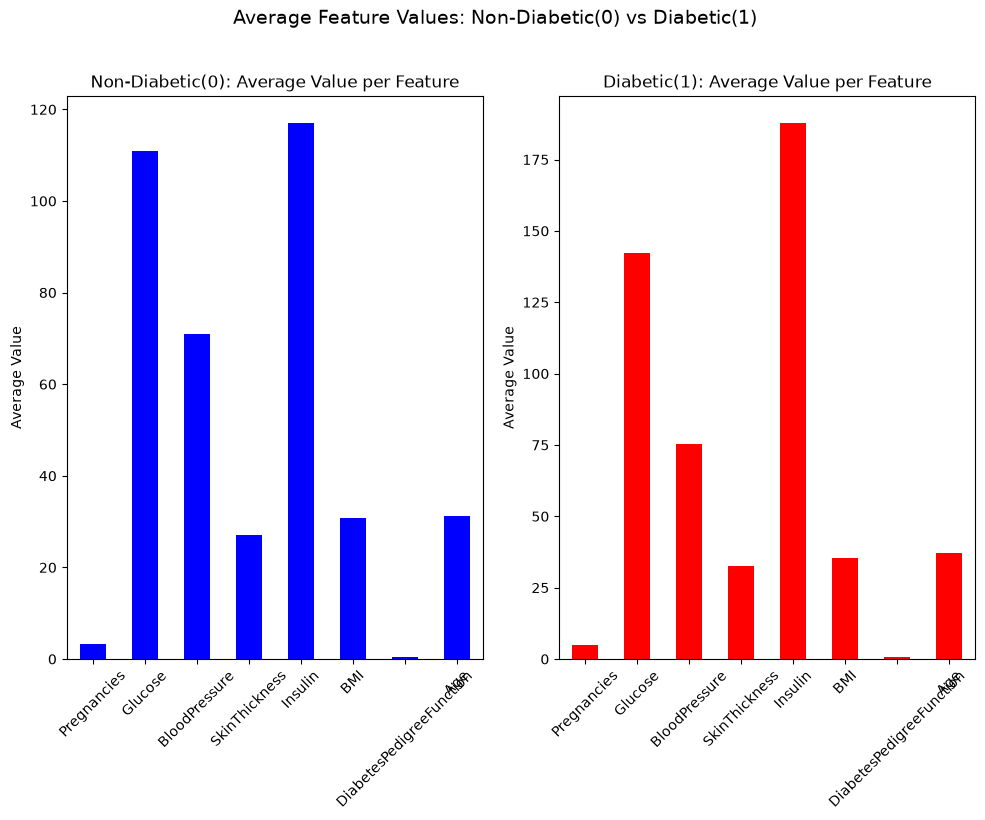


Done.....


In [24]:
#Step4: Visualise Data set
print("\n----------------------------------")
print("          Visualise Data Set")
print("----------------------------------")
OUTPUT_DIR.mkdir(exist_ok=True)

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

averages_by_outcome = df_clean.groupby("Outcome")[features].mean()
 
#plot two chart side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
 
# Left chart: Non-Diabetic (Outcome = 0)
averages_by_outcome.loc[0].plot(kind="bar", ax=axes[0], color="blue")
axes[0].set_title("Non-Diabetic(0): Average Value per Feature")
axes[0].set_ylabel("Average Value")
axes[0].tick_params(axis="x", rotation=45)
 
# Right chart: Diabetic (Outcome = 1)
averages_by_outcome.loc[1].plot(kind="bar", ax=axes[1], color="red")
axes[1].set_title("Diabetic(1): Average Value per Feature")
axes[1].set_ylabel("Average Value")
axes[1].tick_params(axis="x", rotation=45)
 
plt.suptitle("Average Feature Values: Non-Diabetic(0) vs Diabetic(1)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / PLOT_BEFORE, dpi=150, bbox_inches="tight")
print("Saved bar plot before")
plt.show()

print("\nDone.....")

In [25]:
#Step5: Prepare Feature and Target
print("\n------------------------------------")
print("Prepare Feature/Target and split data")
print("--------------------------------------")

feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

target_column = "Outcome"

X = df[feature_columns]  # X usually means the input columns in machine learning examples
y = df[target_column]  # y usually means the value we want to predict

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)
print("\nDone......")


------------------------------------
Prepare Feature/Target and split data
--------------------------------------

Done......


In [26]:
# %% Step6: Train Decision Tree
print("\n----------------------------------")
print("      Train Decision Tree")
print("----------------------------------")

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("\nDone......")


----------------------------------
      Train Decision Tree
----------------------------------

Done......


In [27]:
# %% Step7: Predict and Save Results
print("\n---------------------------------------------------")
print("      Predict and Save Results")
print("-----------------------------------------------------")

predictions = model.predict(X_test)

results_df = X_test.copy()
results_df["actual_outcome"] = y_test.values
results_df["predicted_outcome"] = predictions

results_df.to_csv(OUTPUT_DIR / PREDICTION_RESULT, index=False)
print("\nPrediction result saved.....")

print("\nPrediction Results comparision on test data: ")
print(results_df.to_string(index=False))
print("\nDone...........")


---------------------------------------------------
      Predict and Save Results
-----------------------------------------------------

Prediction result saved.....

Prediction Results comparision on test data: 
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age  actual_outcome  predicted_outcome
           5      126             78             27       22 29.6                     0.439   40               0                  1
           1      143             74             22       61 26.2                     0.256   21               0                  0
           1       96             64             27       87 33.2                     0.289   21               0                  0
           1      180              0              0        0 43.3                     0.282   41               1                  1
           3      125             58              0        0 31.6                     0.151   24               0             

In [28]:
# %% Step8: Evaluate: Check Accuracy and Confusion metrix
print("\n---------------------------------------------------")
print("      Evaluate: Check Accuracy and Confusion metrix")
print("-----------------------------------------------------")

label_order = [0, 1]

accuracy = accuracy_score(y_test, predictions)
matrix = confusion_matrix(y_test, predictions, labels=label_order)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(matrix)

cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

report = classification_report(y_test, predictions, labels=label_order)

print("\n--- Classification report ---")
print(report)

with open(OUTPUT_DIR / EVALUATION_REPORT, "w") as file:
    file.write("-----------------------------------------\n")
    file.write("     Accuracy and Confusion metrix\n")
    file.write("-----------------------------------------\n")
    file.write(f"\nAccuracy: {accuracy}\n")
    file.write(f"\nConfusion Matrix: \n{matrix}\n")
    file.write(f"\nClassificatio Report: ")
    file.write(report)

print("Classification report saved successfully.")
print("\nDone....")



---------------------------------------------------
      Evaluate: Check Accuracy and Confusion metrix
-----------------------------------------------------
Accuracy: 0.7172774869109948
Confusion Matrix:
[[90 34]
 [20 47]]

--- Classification report ---
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       124
           1       0.58      0.70      0.64        67

    accuracy                           0.72       191
   macro avg       0.70      0.71      0.70       191
weighted avg       0.73      0.72      0.72       191

Classification report saved successfully.

Done....


In [29]:
#%% Step9: Export the tree rule as text
print("\n---------------------------------------------------")
print("      Export the tree rule ")
print("-----------------------------------------------------")
tree_rules = export_text(model, feature_names=feature_columns)

with open(OUTPUT_DIR / TREE_RULE, "w", encoding="utf-8") as file:
    file.write(tree_rules)

print("\n--- Tree rules ---")
print(tree_rules)
print("Saved diabetese prediction tree rule")
print("Done....")


---------------------------------------------------
      Export the tree rule 
-----------------------------------------------------

--- Tree rules ---
|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- Glucose <= 151.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  151.50
|   |   |   |--- class: 1
|   |--- BMI >  27.35
|   |   |--- Age <= 30.50
|   |   |   |--- class: 0
|   |   |--- Age >  30.50
|   |   |   |--- class: 1
|--- Glucose >  154.50
|   |--- BMI <= 29.85
|   |   |--- Age <= 25.50
|   |   |   |--- class: 0
|   |   |--- Age >  25.50
|   |   |   |--- class: 1
|   |--- BMI >  29.85
|   |   |--- Insulin <= 544.00
|   |   |   |--- class: 1
|   |   |--- Insulin >  544.00
|   |   |   |--- class: 0

Saved diabetese prediction tree rule
Done....


In [30]:
#%% Step10: Predict New Case
print("\n---------------------------------------------------")
print("      Predict New Case ")
print("-----------------------------------------------------")
new_record = pd.DataFrame(
    {
        "Pregnancies": [0,3,1,5,2],
        "Glucose": [140,110,80,112,130],
        "BloodPressure": [66,74,90,69,92],
        "SkinThickness": [35,19,48,36,40],
        "Insulin": [180,88,100,225,333],
        "BMI": [34.2,22.3,40.5,33.2,38.4],
        "DiabetesPedigreeFunction": [1.351,0.645,0.734,1.298,0.345],
        "Age": [30,44,29,56,33]

    }
)

new_predictions = model.predict(new_record)

print("\n--- New predictions ---")
print("New predictions:", new_predictions)

results = new_record.copy()
results["Predicted_Outcome"] = new_predictions

print(results.to_string(index=False))

print("Done....")


---------------------------------------------------
      Predict New Case 
-----------------------------------------------------

--- New predictions ---
New predictions: [0 0 0 1 1]
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age  Predicted_Outcome
           0      140             66             35      180 34.2                     1.351   30                  0
           3      110             74             19       88 22.3                     0.645   44                  0
           1       80             90             48      100 40.5                     0.734   29                  0
           5      112             69             36      225 33.2                     1.298   56                  1
           2      130             92             40      333 38.4                     0.345   33                  1
Done....
